# phase2 / notebook 2 — 500-epoch convergence study

Extended training of the same four architectures from notebook 1, this time for 500 epochs at consistent hyperparameters.

# 1. Overview

## 1.1 Task & motivation

Compare how all four architectures behave over a longer training horizon. Notebook 1 showed GAT winning at 100 epochs; this notebook checks whether the others would close the gap with more training.

## 1.2 Dataset summary

Reddit2 with `NeighborLoader([20, 15, 10])`.

## 1.3 Approach in one paragraph

Run each of {FeedFwd, GraphConv, GraphSAGE, GraphAttention} for 500 epochs at matched hyperparameters; plot validation loss trajectories; identify the winner.

## 1.4 Libraries used

Same stack as notebook 1.

# 2. Environment & Setup

## 2.1 Imports

Cell 0: torch, PyG, nnx.

## 2.2 Configuration / hyperparameters

`N_NEIGHBORS = [20, 15, 10]`, `n_heads = 4`, `n_epochs = 500`.

## 2.3 Reproducibility (seed, device)

`nnx` defaults; GPU when available.

# 3. Data

## 3.1 Loading

Cell 1: `pyg.datasets.Reddit2`.

## 3.2 Inspection / EDA

Covered in phase 1.

## 3.3 Preprocessing & splits

PyG defaults.

# 4. Model

## 4.1 Architecture

Same four architectures, hidden `[128]`, consistent across runs.

## 4.2 Loss & optimizer

Cross-entropy, one fixed optimizer choice (best from notebook 1).

## 4.3 Why this design

Controls for everything except architecture type so the convergence comparison is fair.

# 5. Training

## 5.1 Training loop

`nnx` loop, 500 epochs per architecture.

## 5.2 Metrics tracked

Per-iteration train and validation loss.

## 5.3 Run-time notes

Tier B. Original Aug-2023 outputs preserved.

# 6. Evaluation & Results

## 6.1 Test-set evaluation

Best run by final validation loss.

## 6.2 Visualizations

Cell 7: `Utils.multi_line_plot` of the validation-loss trajectories.

## 6.3 Discussion

GraphAttention reached 0.2521; GraphSAGE and GraphConv tracked each other; FeedFwd plateaued early — confirming graph structure is essential for this task.


In [1]:
import torch_geometric as pyg


from nnx.utils import Utils
from nnx.nn.params.nn_params import NNParams
from nnx.nn.nn_model import NNModel
from nnx.nn.params.nn_train_params import NNTrainParams
from nnx.nn.enum.optims import Optims
from nnx.nn.params.nn_optim_params import NNOptimParams
from nnx.nn.params.nn_model_params import NNModelParams
from nnx.nn.enum.devices import Devices
from nnx.nn.enum.losses import Losses
from nnx.nn.enum.nets import Nets


In [2]:
dataset = pyg.datasets.Reddit2(
    root="./data"
    , transform=pyg.transforms.Compose(
        [
            pyg.transforms.NormalizeFeatures()
            , pyg.transforms.ToSparseTensor()
        ]
    )
)

In [3]:
N_NEIGHBORS = [20, 15, 10]

train_loader = pyg.loader.NeighborLoader(
    data=dataset._data
    , shuffle=True
    , num_workers=4
    , num_neighbors=N_NEIGHBORS
    , input_nodes=dataset._data.train_mask
    , batch_size=int(dataset._data.train_mask.sum())
)

val_loader = pyg.loader.NeighborLoader(
    data=dataset._data
    , shuffle=False
    , num_workers=4
    , num_neighbors=N_NEIGHBORS
    , input_nodes=dataset._data.val_mask
    , batch_size=int(dataset._data.val_mask.sum())
)

print(len(val_loader.dataset))
print(len(train_loader.dataset))

/opt/conda/lib/python3.10/site-packages/torch_geometric/sampler/neighbor_sampler.py:50: UserWarning: Using '{self.__class__.__name__}' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn("Using '{self.__class__.__name__}' without a "


23699
153932


In [4]:
n_heads = 4
n_epochs = 500
optims = [Optims.ADAM]
lrs = [1e-2]
weight_decay = 5e-4

dropout_probs = [0.25]
hidden_dimss = [
    [128]
]

net_specs = [
    (Nets.GRAPH_ATT,  n_heads),
    (Nets.GRAPH_SAGE, None),
    (Nets.GRAPH_CONV, None),
    (Nets.FEED_FWD,   None),
]

models = [
    NNModel(
        params=NNModelParams(net=net_enum, device=Devices.CPU, loss=Losses.CROSS_ENTROPY),
        net_params=NNParams(
            n_heads=heads,
            hidden_dims=hidden_dims,
            dropout_prob=dropout_prob,
            input_dim=dataset.num_features,
            output_dim=dataset.num_classes,
        ),
    )
        for hidden_dims in hidden_dimss
        for dropout_prob in dropout_probs
        for (net_enum, heads) in net_specs
]

train_params = [
    NNTrainParams(
        n_epochs=n_epochs,
        optim=NNOptimParams(name=optim, max_lr=lr, weight_decay=weight_decay),
    )
        .with_train_loader(value=train_loader)
        .with_val_loader(value=val_loader)
        for lr in lrs
        for optim in optims
]


In [5]:
trains = {
    train_str: (model, train_idps)
        for model, (train_str, train_idps) in [
            (model, model.train(params=train_param))
                for model in models
                for train_param in train_params
        ]
}

GraphAttNN={dims=[602, 128, 41], dropout=0.25, heads=4} x Train=[epochs=500, optim=adam, lr=1e-02, weight_decay=5e-04]: 100%|██████████| 500/500 [4:48:01<00:00, 34.56s/it, error: 0.2533]  
GraphSageNN={dims=[602, 128, 41], dropout=0.25} x Train=[epochs=500, optim=adam, lr=1e-02, weight_decay=5e-04]: 100%|██████████| 500/500 [2:03:23<00:00, 14.81s/it, error: 0.4666]  
GraphConvNN={dims=[602, 128, 41], dropout=0.25} x Train=[epochs=500, optim=adam, lr=1e-02, weight_decay=5e-04]: 100%|██████████| 500/500 [1:46:15<00:00, 12.75s/it, error: 0.5188]
FeedFwdNN={dims=[602, 128, 41], dropout=0.25} x Train=[epochs=500, optim=adam, lr=1e-02, weight_decay=5e-04]: 100%|██████████| 500/500 [59:01<00:00,  7.08s/it, error: 0.6206] 


In [6]:
top_model_names = [
    kvp[0] for kvp in sorted(
        list(trains.items())
        , key=lambda kvp: min(
            kvp[1][1]
            , key=lambda idp: idp.val_error
        ).val_error
    )[:10]
]

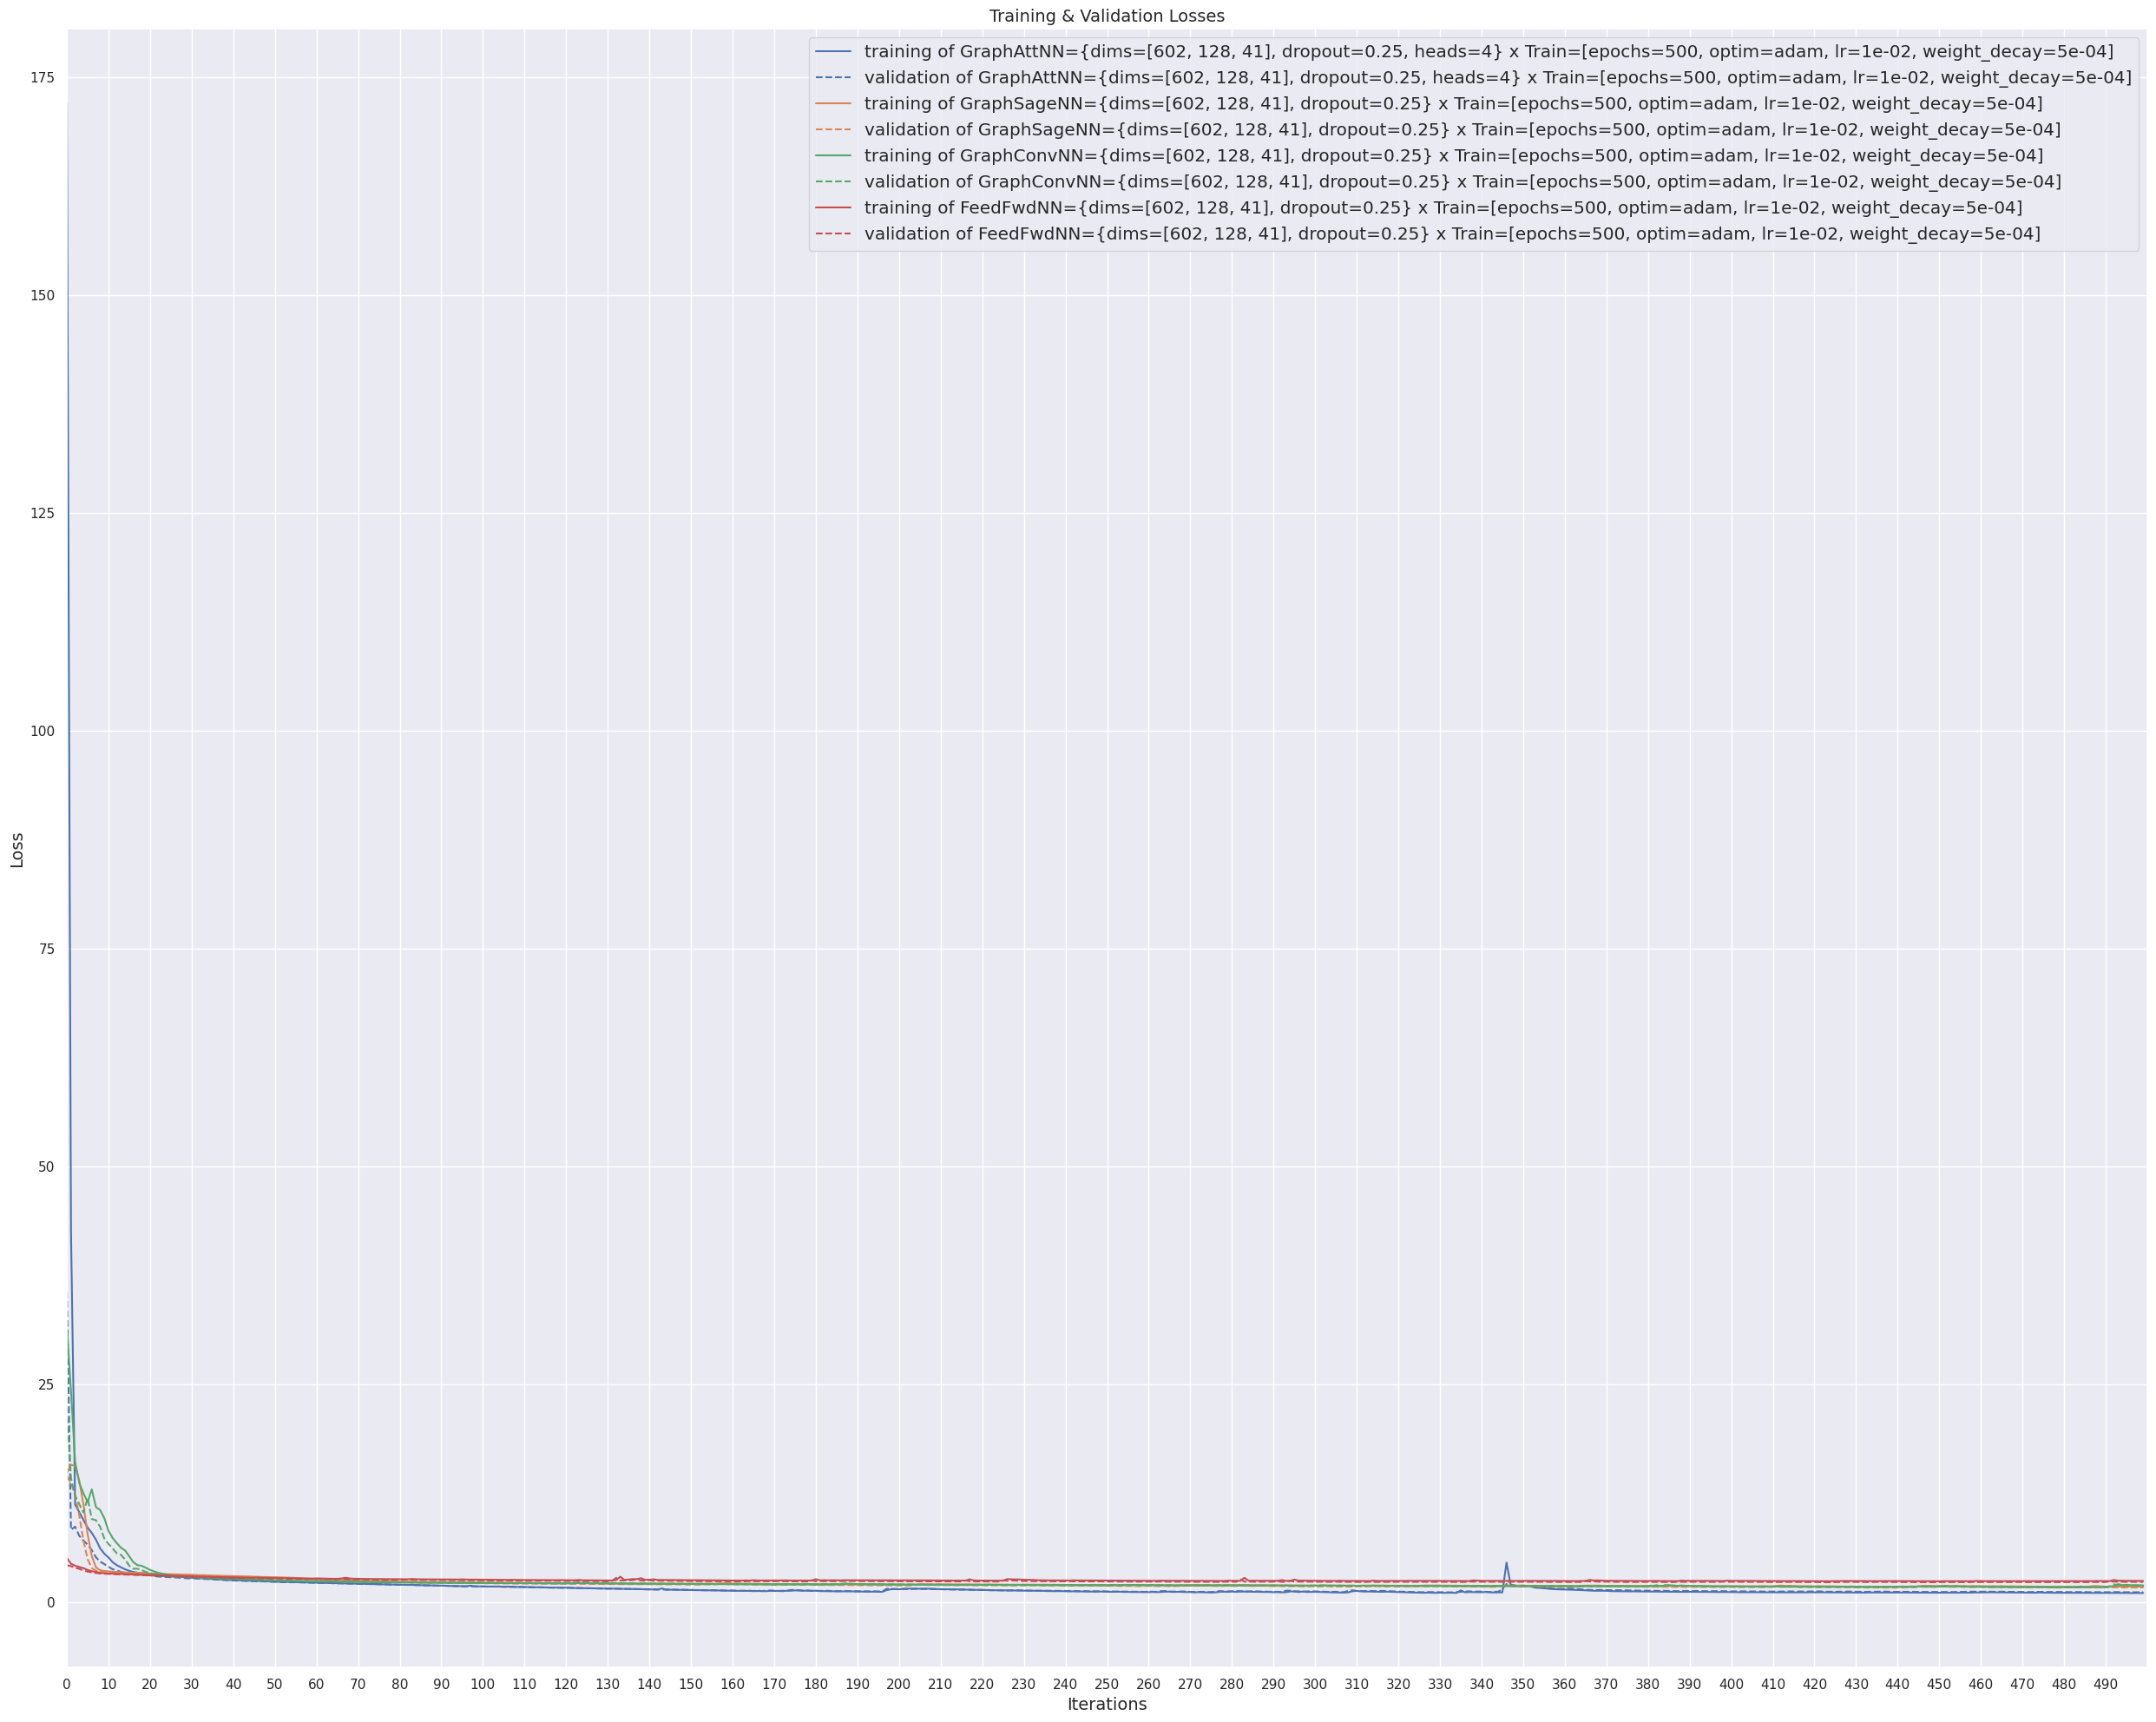

In [11]:
%matplotlib inline

Utils.multi_line_plot(
    x_ticks_inc=10
    , fig_size=(25, 20)
    , y_axis_label="Loss"
    , x_axis_label="Iterations"
    , title="Training & Validation Losses"
    , x=[idp.iter_idx for idp in trains[top_model_names[0]][1]]
    , yss_legend=[[f"{loss_type} of {model_name}" for loss_type in ["training", "validation"]] for model_name in top_model_names]
    , yss=[[[model_idp.train_loss for model_idp in trains[model_name][1]], [model_idp.val_loss for model_idp in trains[model_name][1]]] for model_name in top_model_names]
)

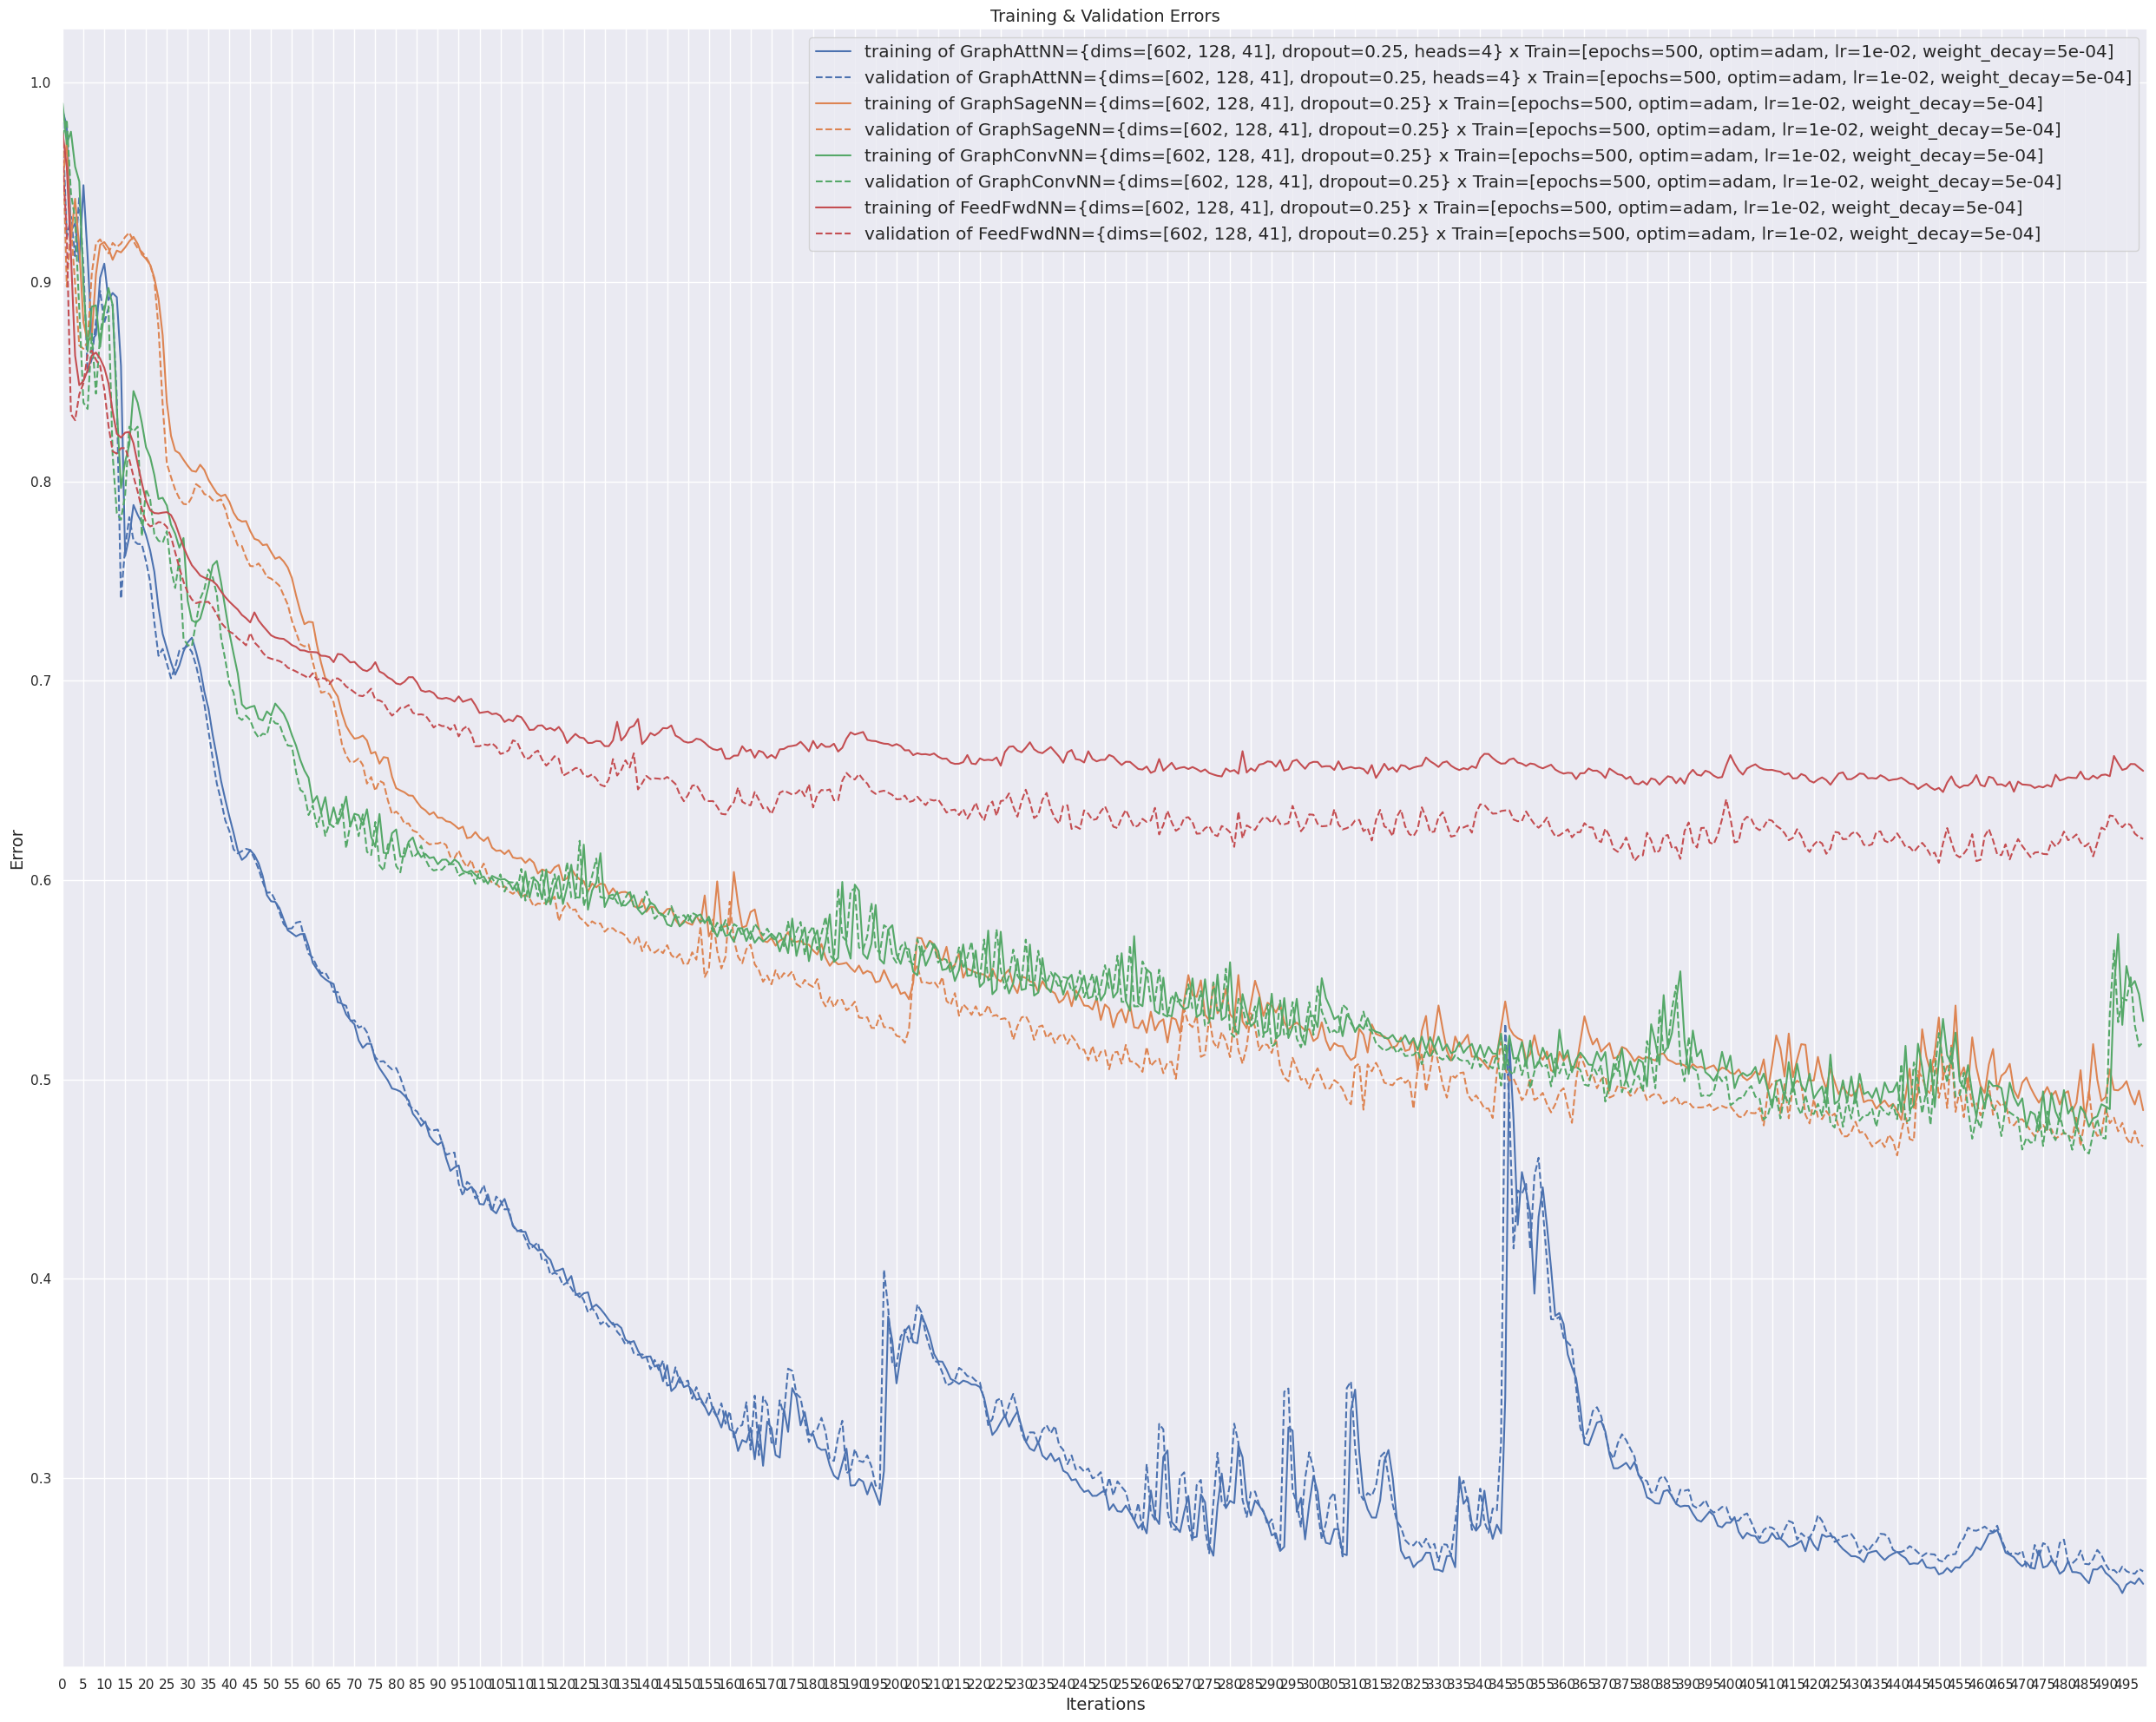

In [12]:
Utils.multi_line_plot(
    x_ticks_inc=5
    , fig_size=(25, 20)
    , y_axis_label="Error"
    , x_axis_label="Iterations"
    , title="Training & Validation Errors"
    , x=[idp.iter_idx for idp in trains[top_model_names[0]][1]]
    , yss_legend=[[f"{loss_type} of {model_name}" for loss_type in ["training", "validation"]] for model_name in top_model_names]
    , yss=[[[model_idp.train_error for model_idp in trains[model_name][1]], [model_idp.val_error for model_idp in trains[model_name][1]]] for model_name in top_model_names]
)

In [13]:
print(f"best model is {top_model_names[0]} which achieves validation error of {min(trains[top_model_names[0]][1], key=lambda idp: idp.val_error).val_error:.4f}")

best model is GraphAttNN={dims=[602, 128, 41], dropout=0.25, heads=4} x Train=[epochs=500, optim=adam, lr=1e-02, weight_decay=5e-04] which achieves validation error of 0.2521
